# **Importation des librairies et chargement du jeu de donnée segmenté**

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df=pd.read_csv("../data/3_processed/paquet_phrases_lemm.csv") # Chargement du DataFrame nettoyé à partir du fichier CSV

In [3]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...


# **Vérification de la lemmatisation et de la création de la matrice de terme-document**

In [4]:
vectorizer = TfidfVectorizer( 
    min_df=3, # Exclure les termes qui apparaissent dans moins de 3 segments de texte.
    max_df=0.8 # Exclure les termes qui apparaissent dans plus de 80% des segments de texte, car ils sont probablement trop fréquents pour être informatifs.
    )

X = vectorizer.fit_transform(df["phrases_lemm"])  
#Appliquer le TF-IDF vectorizer sur les segments de texte nettoyés pour obtenir une matrice de caractéristiques (termes pondérés par leur importance dans les segments).

X.shape

(5327, 11640)

Il y a un choix qui a été fait pour faire la vectorisation à partir des segments du texte. 

- Les paragraphes sont **min_df=3 et max_df=0.8**, ce qui signifie que les mots qui apparaissent dans **moins de 3 segments de texte ou dans plus de 80% des segments** de texte seront exclus de la matrice de termes. Ce choix a été choisi apres avoir teste differentes valeurs de min_df et max_df, et en observant les résultats obtenus. La selection a été fait de façon qualitative, en observant les mots les plus fréquents et les moins fréquents dans les segments de texte, et en ajustant les valeurs de min_df et max_df pour obtenir une matrice de termes qui capture les mots les plus pertinents pour l'analyse des topics.

## **Tentative de trouver le K optimal pour la NMF**

/Users/morganrichard/analyse_topic_zola/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


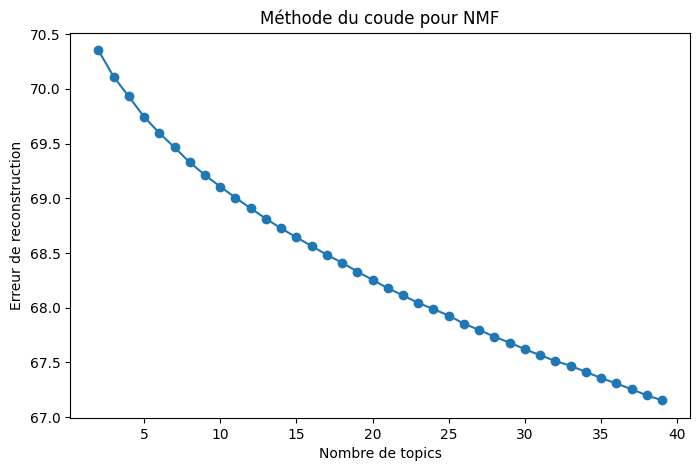

In [5]:
errors = []
k_values = range(2, 40)

for k in k_values:
    nmf = NMF(
        n_components=k,
        random_state=42,
        init="nndsvda",
        max_iter=500
    )
    
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker="o")
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

- Apres avoir utilisé la méthode du coude nous ne trouvons **pas de coude clair**, ce qui rend difficile de choisir un K optimal pour la NMF. Il ne reste donc plus qu'à tester différents K et à observer les resultats obtenus pour choisir le K qui donne les topics les plus cohérents et les plus interprétables.

- Je vais tester les K suivants : **10, 15, 20, 30 et 35**.

# **Fonction pour afficher les topics et les mots les plus importants pour chaque topic**

In [6]:
def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")



feature_names = vectorizer.get_feature_names_out()

#for k in  [10, 15, 20, 30, 35 ]: # On teste différents nombres de topics (de 5 à 15) pour trouver le nombre optimal de topics pour notre analyse.
    
    #print(f"\n NMF avec {k} topics") 
nmf = NMF(n_components=29, 
          random_state=42,
          init="nndsvda",
          solver="cd",
          max_iter=1000,
          
            )
W = nmf.fit_transform(X)
afficher_topics(nmf, feature_names)

print("Erreur :", nmf.reconstruction_err_)

Topic 1 : femme | mari | chose | bon | homme | cher | ménage | histoire | vrai | plaisir
Topic 2 : travail | peuple | vie | usine | bonheur | justice | ouvrier | œuvre | humanité | terre
Topic 3 : arbre | soleil | herbe | eau | ciel | jardin | ombre | terre | feuille | branche
Topic 4 : million | bourse | cours | action | universelle | banque | affaire | agent | hausse | titre
Topic 5 : abbé | prêtre | curé | église | jardin | trouche | soutane | sous | préfecture | évêque
Topic 6 : table | verre | vin | pain | café | eau | maman | assiette | bon | petit
Topic 7 : main | oeil | mort | bras | sang | tête | corps | face | voix | lèvre
Topic 8 : franc | argent | billet | somme | mois | sou | chiffre | pièce | fortune | poche
Topic 9 : monsieur | dame | porte | vou | bon | air | voix | tante | main | mot
Topic 10 : rue | maison | quartier | trottoir | boutique | boulevard | ville | place | voiture | chaussée
Topic 11 : train | gare | heure | machine | chef | voiture | voie | wagon | expres

In [7]:
W_norm = W / W.sum(axis=1, keepdims=True) 
# Normalisation de la matrice W pour que les contributions des topics soient comparables entre les segments de texte,
#en divisant chaque ligne de W par la somme de ses éléments. Cela permet d'obtenir des poids

df["topic_dominant"] = W_norm.argmax(axis=1) 
# On ajoute une colonne "topic_dominant" au DataFrame qui contient l'indice du topic dominant pour chaque segment de texte, 
# c'est-à-dire le topic avec la plus grande contribution dans la matrice W normalisée.


df["poids_topic"] = W_norm.max(axis=1) 
# On ajoute une colonne "poids_topic" qui contient la valeur du poids du topic dominant pour chaque segment de texte,
# ce qui permet de mesurer à quel point le topic dominant est représentatif du segment de texte

In [8]:
df # Affichage du DataFrame avec les nouvelles colonnes "topic_dominant" et "poids_topic".

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,topic_dominant,poids_topic
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,22,0.210721
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,20,0.200500
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,20,0.177862
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,28,0.178062
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,26,0.208460
...,...,...,...,...,...,...
5322,1894_1_Lourdes._clean.txt,193,"Le diable dans cette vie si pure, dans cette â...",diable vie pur âme péché coup souffrance pardo...,11,0.464836
5323,1894_1_Lourdes._clean.txt,194,Des milliers de pèlerins avaient beau se rendr...,millier pèlerin beau année peuple tentative ré...,11,0.347142
5324,1894_1_Lourdes._clean.txt,195,"Elle était sa maîtresse souveraine, elle le te...",maîtresse souverain milieu obscurité avortemen...,1,0.406650
5325,1894_1_Lourdes._clean.txt,196,Et n’aurait-il pas fallu la venue d’un nouveau...,venue sauveur souffle prodigieux volée cloche ...,1,0.331730


In [9]:
for topic in sorted(df["topic_dominant"].unique()):
    print(f"\n TOPIC {topic+1} ")
    subset = (
        df[df["topic_dominant"] == topic] 
        .sort_values("poids_topic", ascending=False)
        .head(5)
    )
    for _, row in subset.iterrows():
        print(f"\nTitre : {row['nom_fichier']} | Poids : {row['poids_topic']:.4f}")
        print(row["phrases_paquet"][:500])


 TOPIC 1 

Titre : 1880_9_Nana._clean.txt | Poids : 0.4935
mon cher, ils ne se sont jamais touchés, pas ça!... Elle était très portée là-dessus, tu comprends. Lui, godiche, n’a pas su... Si bien que, la croyant en bois, il est allé ailleurs avec des roulures qui l’ont régalé de toutes sortes d’horreurs, tandis qu’elle, de son côté, s’en payait d’aussi raides avec des garçons plus malins que son cornichon de mari... Et ça tourne toujours comme ça, faute de s’entendre. Je le sais bien, moi! Muffat, pâlissant, comprenant enfin les allusions, voulut la fair

Titre : 1899_1_Fecondite._clean.txt | Poids : 0.3731
elle doit être amusante. Puis, comme s’il oubliait un point important: Ah! vous savez qu’elle a déjà vu le loup. Je me suis renseigne, elle couchait à seize ans avec le garçon du marchand de vin, qui loue aux Moineaud les trois petites pièces, où toute la nichée s’entasse... Des vierges, ce n’est pas mon goût, et d’ailleurs il n’en faut pas: c’est trop grave. Mathieu, qui écoutait u

In [10]:
noms_topics_nmf = {
    1: "Les relations conjugales et la vie domestique",
    2: "Le travail, le peuple et la justice sociale",
    3: "La nature et le paysage",
    4: "La bourse, la finance et les affaires",
    5: "Le clergé et la paroisse",
    6: "La table et les repas",
    7: "Le corps, la souffrance et la mort",
    8: "L’argent et la fortune",
    9: "Les conversations et les scènes domestiques",
    10: "Le quartier et la ville",
    11: "Le monde ferroviaire",
    12: "Le miracle, le pèlerinage et la religion",
    13: "Les liens familiaux, l’écriture et les proches",
    14: "Le pouvoir religieux",
    15: "L’école et l’instruction",
    16: "La famille, la terre et le monde paysan",
    17: "Le monde ouvrier et la mine",
    18: "La guerre, les soldats et l’armée",
    19: "Le désir, le mariage et les relations amoureuses",
    20: "Le magasin, la vente et les clientes",
    21: "Le monde médical et la santé",
    22: "Le monde artistique et la peinture",
    23: "La chambre, le lit et l’espace intime",
    24: "L’enfance, la maternité et la pauvreté",
    25: "Le commerce alimentaire et les halles",
    26: "Le salon, l’aristocratie et les scènes mondaines",
    27: "Le pouvoir politique et les affaires publiques",
    28: "L’amour, le bonheur et les sentiments",
    29: "L’insurrection et la révolution"
}

In [11]:
df["nom_topic"] = df["topic_dominant"].map(noms_topics_nmf) 
# On ajoute une colonne "nom_topic" qui contient le nom du topic dominant pour chaque segment de texte,
# en utilisant un dictionnaire de correspondance entre les indices de topics et leurs noms respectifs

In [12]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,topic_dominant,poids_topic,nom_topic
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,22,0.210721,Le monde artistique et la peinture
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,20,0.200500,"Le magasin, la vente et les clientes"
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,20,0.177862,"Le magasin, la vente et les clientes"
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,28,0.178062,"L’amour, le bonheur et les sentiments"
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,26,0.208460,"Le salon, l’aristocratie et les scènes mondaines"


In [17]:
df['nom_topic'].value_counts()

nom_topic
Le pouvoir politique et les affaires publiques      335
Le monde artistique et la peinture                  327
Le salon, l’aristocratie et les scènes mondaines    266
Le commerce alimentaire et les halles               266
Les relations conjugales et la vie domestique       262
Le travail, le peuple et la justice sociale         229
La chambre, le lit et l’espace intime               221
La table et les repas                               218
Le clergé et la paroisse                            214
La bourse, la finance et les affaires               210
Les conversations et les scènes domestiques         205
Le corps, la souffrance et la mort                  187
La famille, la terre et le monde paysan             185
L’école et l’instruction                            180
Le monde ferroviaire                                177
La guerre, les soldats et l’armée                   173
Le monde ouvrier et la mine                         173
Le pouvoir religieux                  

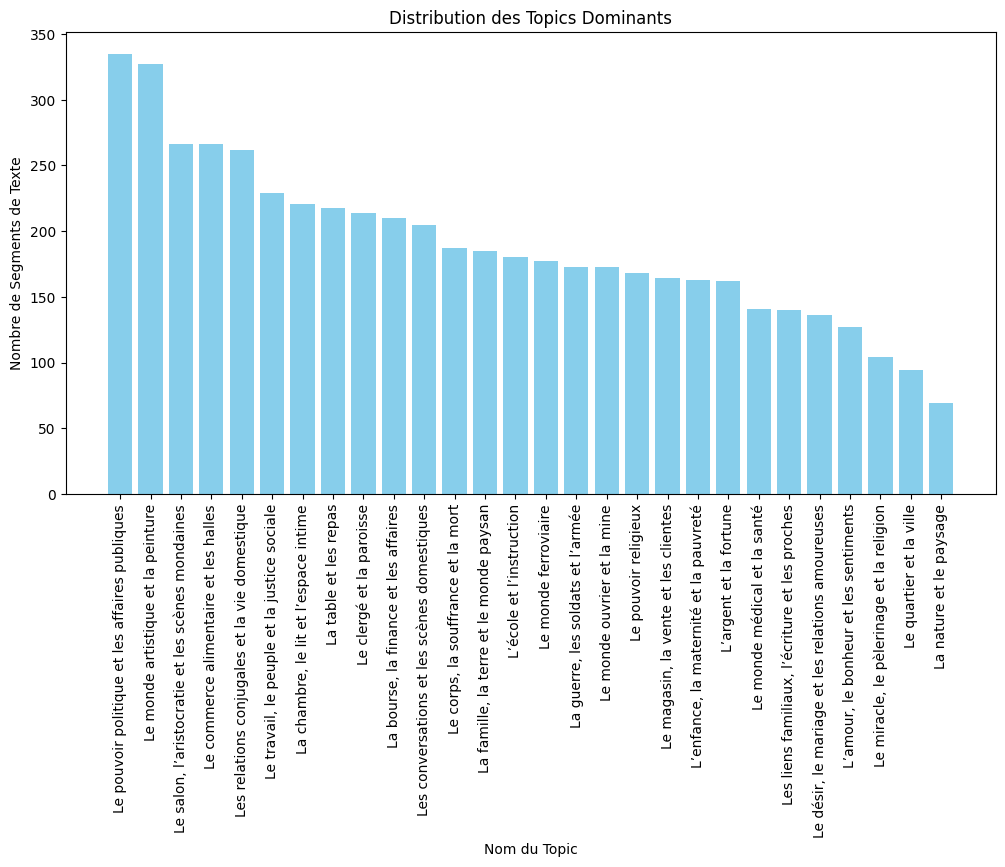

In [18]:
nb_topics = df['nom_topic'].value_counts().reset_index()
nb_topics.columns = ['nom_topic', 'count']
plt.figure(figsize=(12, 6))
plt.bar(nb_topics['nom_topic'], nb_topics['count'], color='skyblue')
plt.xlabel('Nom du Topic')
plt.ylabel('Nombre de Segments de Texte')
plt.title('Distribution des Topics Dominants')
plt.xticks(rotation=90)
plt.show()

In [13]:
W = nmf.fit_transform(X)
H = nmf.components_

df["topic_dominant"] = W.argmax(axis=1) + 1
df["score_topic_dominant"] = W.max(axis=1)

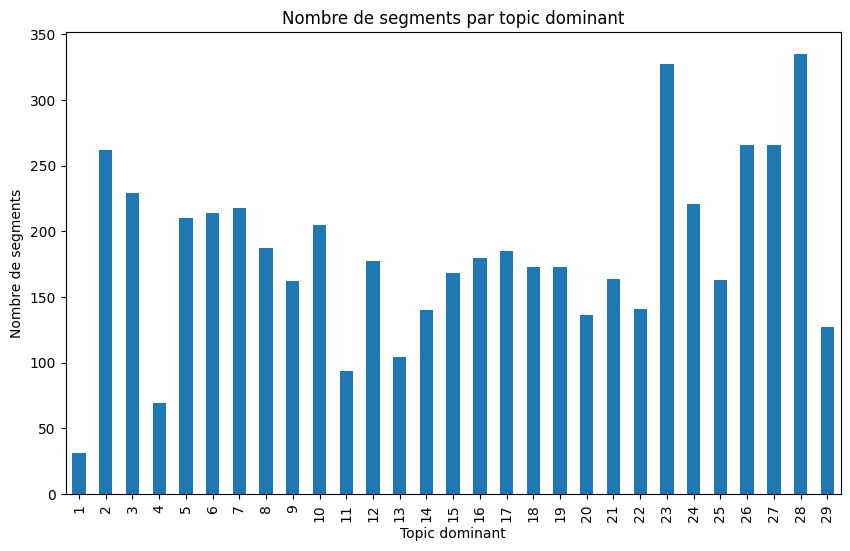

In [14]:
nb_segments = df["topic_dominant"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
nb_segments.plot(kind="bar")

plt.title("Nombre de segments par topic dominant")
plt.xlabel("Topic dominant")
plt.ylabel("Nombre de segments")
plt.show()

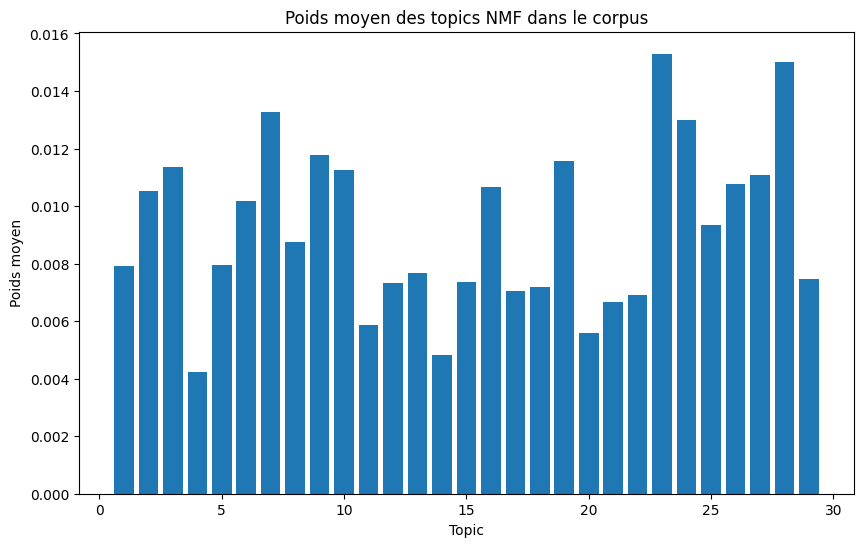

In [15]:
topic_weights = W.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(topic_weights) + 1), topic_weights)

plt.title("Poids moyen des topics NMF dans le corpus")
plt.xlabel("Topic")
plt.ylabel("Poids moyen")
plt.show()

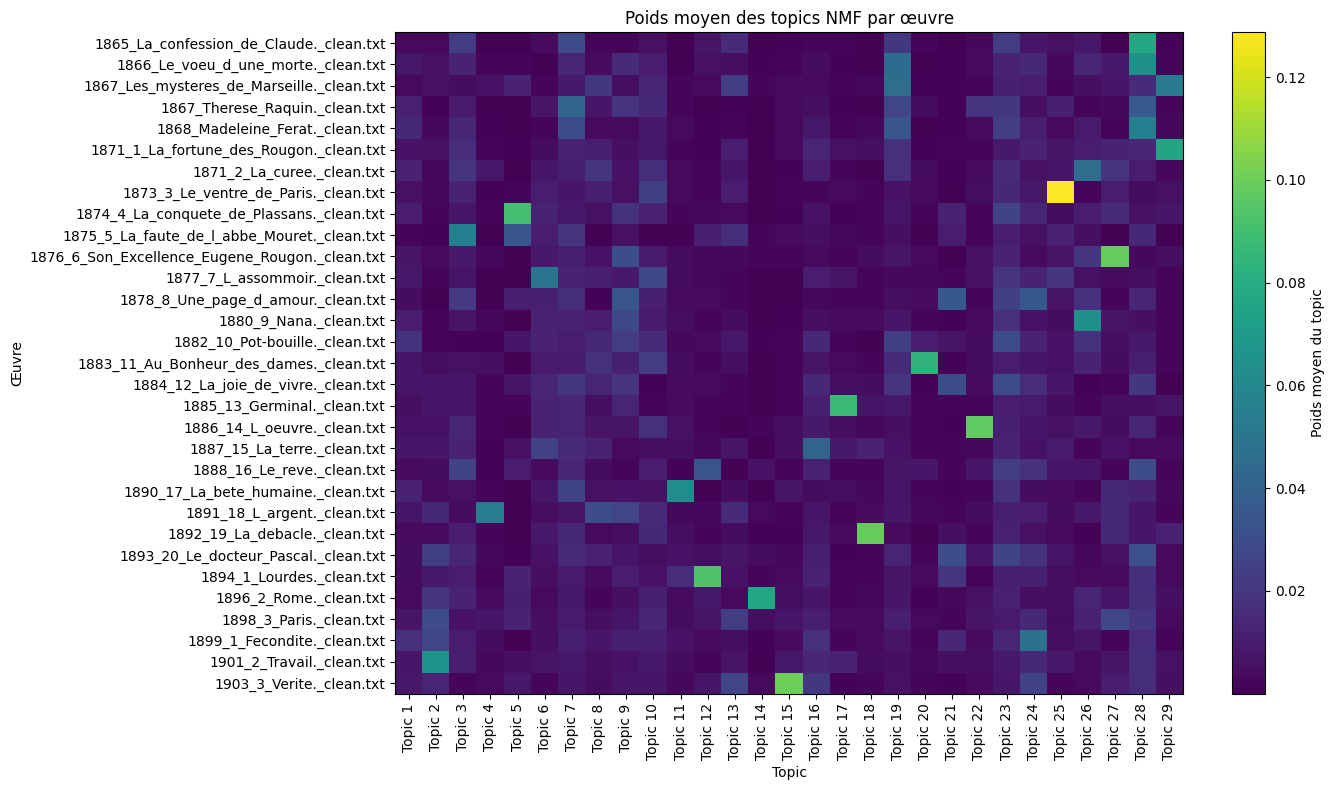

In [16]:
topics_df = pd.DataFrame(
    W,
    columns=[f"Topic {i+1}" for i in range(W.shape[1])]
)
topics_df["nom_fichier"] = df["nom_fichier"].values

table_topics = topics_df.groupby("nom_fichier").mean()

plt.figure(figsize=(14, 8))
plt.imshow(table_topics, aspect="auto")

plt.xticks(range(len(table_topics.columns)), table_topics.columns, rotation=90)
plt.yticks(range(len(table_topics.index)), table_topics.index)

plt.title("Poids moyen des topics NMF par œuvre")
plt.xlabel("Topic")
plt.ylabel("Œuvre")
plt.colorbar(label="Poids moyen du topic")
plt.tight_layout()
plt.show()